In [1]:
!pip install pandas numpy scikit-learn matplotlib seaborn

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import LinearSVC
from sklearn.metrics import classification_report, confusion_matrix

In [3]:
# Load data
df = pd.read_csv("netflix_reviews.csv")

# Drop missing content
df = df.dropna(subset=["content", "score"])

# Sample 10,000 rows to speed things up (optional for full dataset)
df = df.sample(n=10000, random_state=42).reset_index(drop=True)

# Label sentiment
def label_sentiment(score):
    if score <= 2:
        return "Negative"
    elif score == 3:
        return "Neutral"
    else:
        return "Positive"

df["sentiment"] = df["score"].apply(label_sentiment)


In [4]:
# TF-IDF Vectorizer
vectorizer = TfidfVectorizer(stop_words='english', max_features=2000)

# Transform text to vector
X = vectorizer.fit_transform(df["content"])
y = df["sentiment"]


In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)


In [6]:
# Train fast linear SVM
svm_model = LinearSVC()
svm_model.fit(X_train, y_train)


LinearSVC()

              precision    recall  f1-score   support

    Negative       0.78      0.85      0.81       958
     Neutral       0.27      0.09      0.13       199
    Positive       0.78      0.83      0.80       843

    accuracy                           0.76      2000
   macro avg       0.61      0.59      0.58      2000
weighted avg       0.73      0.76      0.74      2000



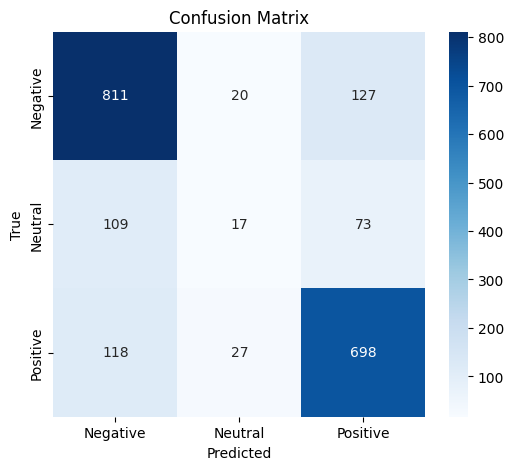

In [7]:
# Predict
y_pred = svm_model.predict(X_test)

# Report
print(classification_report(y_test, y_pred))

# Confusion matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=svm_model.classes_,
            yticklabels=svm_model.classes_)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix")
plt.show()
